In [1]:
import pandas as pd
import numpy as np
data_bengaluru = pd.read_csv("/content/bengaluru_house_prices.csv")

In [2]:
data_bengaluru.shape

(13320, 9)

In [3]:
data_bengaluru.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [4]:
data_bengaluru.head(20)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [5]:
data_bengaluru.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [6]:
data_bengaluru.describe().T

,count,mean,std,min,25%,50%,75%,max
bath,13247.0,2.692610,1.341458,1.0,2.0,2.0,3.0,40.0
balcony,12711.0,1.584376,0.817263,0.0,1.0,2.0,2.0,3.0
price,13320.0,112.565627,148.971674,8.0,50.0,72.0,120.0,3600.0


In [7]:
data_bengaluru.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [8]:
data_bengaluru = data_bengaluru.drop_duplicates()

data_bengaluru = data_bengaluru.drop("society", axis=1)

In [9]:
data_bengaluru["size"] = data_bengaluru["size"].str.split().str[0]
data_bengaluru["size"] = pd.to_numeric(data_bengaluru["size"], errors="coerce")

In [10]:
data_bengaluru["total_sqft"] = pd.to_numeric(
    data_bengaluru["total_sqft"],
    errors="coerce"
)

In [11]:
data_bengaluru["bath"] = data_bengaluru["bath"].fillna(
    data_bengaluru["bath"].median()
)

data_bengaluru["balcony"] = data_bengaluru["balcony"].fillna(
    data_bengaluru["balcony"].median()
)

data_bengaluru = data_bengaluru.dropna()

In [12]:
data_bengaluru["availability"] = data_bengaluru["availability"].apply(
    lambda x: 1 if x == "Ready To Move" else 0
)

In [13]:
data_bengaluru["location"] = data_bengaluru["location"].str.strip()

location_count = data_bengaluru["location"].value_counts()

data_bengaluru["location"] = data_bengaluru["location"].apply(
    lambda x: "other" if location_count[x] <= 10 else x
)

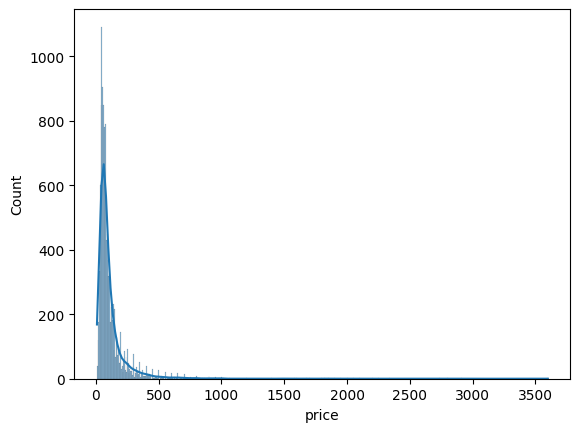

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data_bengaluru["price"], kde=True)
plt.show()

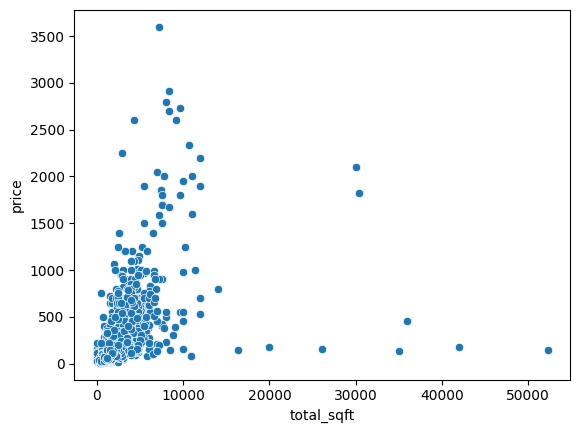

In [15]:
sns.scatterplot(
    x="total_sqft",
    y="price",
    data=data_bengaluru
)
plt.show()

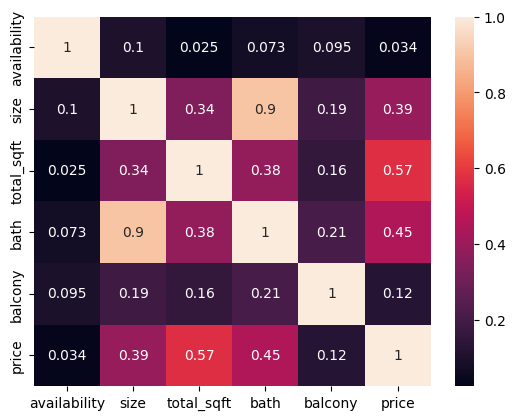

In [16]:
sns.heatmap(
    data_bengaluru.select_dtypes(include=np.number).corr(),
    annot=True
)
plt.show()

In [17]:
data_bengaluru = data_bengaluru[
    data_bengaluru["total_sqft"] / data_bengaluru["size"] >= 300
]

data_bengaluru = data_bengaluru[
    data_bengaluru["bath"] <= data_bengaluru["size"] + 2
]

In [18]:
data_bengaluru = pd.get_dummies(
    data_bengaluru,
    columns=["area_type", "location"],
    drop_first=True
)

In [19]:
from sklearn.model_selection import train_test_split
X = data_bengaluru.drop("price", axis=1)
y = data_bengaluru["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation="relu"))
model.add(Dense(16, activation="relu"))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [23]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 22555.6914 - mae: 74.0218 - val_loss: 16655.3965 - val_mae: 55.0665
Epoch 2/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12651.1025 - mae: 47.3454 - val_loss: 14558.5312 - val_mae: 47.1309
Epoch 3/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11584.3027 - mae: 43.9455 - val_loss: 13633.5732 - val_mae: 46.5373
Epoch 4/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11202.4717 - mae: 41.9978 - val_loss: 13473.4775 - val_mae: 43.0937
Epoch 5/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10775.8730 - mae: 40.6244 - val_loss: 12992.4072 - val_mae: 46.8266
Epoch 6/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10636.1992 - mae: 39.9092 - val_loss: 13167.6064 - val_mae: 40.5621
Epoch 7/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10479.4658 - mae: 39.2072 - val_loss: 12655.6777 - val_mae: 40.7921
Epoch 8/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10239.9600 - mae: 38.2105 - val_loss

# Evaluation

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)
print("R2 =", r2)

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE = 33.53080643654273
MSE = 8260.39661971616
RMSE = 90.88672411147934
R2 = 0.6322879319679104
